In [ ]:
# Download dataset using kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
print("Path to dataset files:", path)

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

# Load the dataset from the kagglehub download path
# The dataset file is typically named 'AB_NYC_2019.csv' within the downloaded directory
csv_path = os.path.join(path, "AB_NYC_2019.csv")
df = pd.read_csv(csv_path)

# Apply the preprocessing steps mentioned (example)
# Removing rows where 'last_review' or 'reviews_per_month' is NaN
df_clean = df.dropna(subset=['last_review', 'reviews_per_month']).copy()
# Converting 'last_review' to datetime and creating 'days_since_last_review'
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'])
df_clean['days_since_last_review'] = (pd.to_datetime('2019-12-31') - df_clean['last_review']).dt.days
# Removing extreme price outliers
df_clean = df_clean[df_clean['price'] <= 1000]

print(f"Dataset loaded successfully with {len(df_clean)} rows after preprocessing")

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data
Dataset loaded successfully with 38736 rows after preprocessing


/tmp/ipython-input-85374419.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='neighbourhood_group', y='price', ax=ax, palette='viridis')


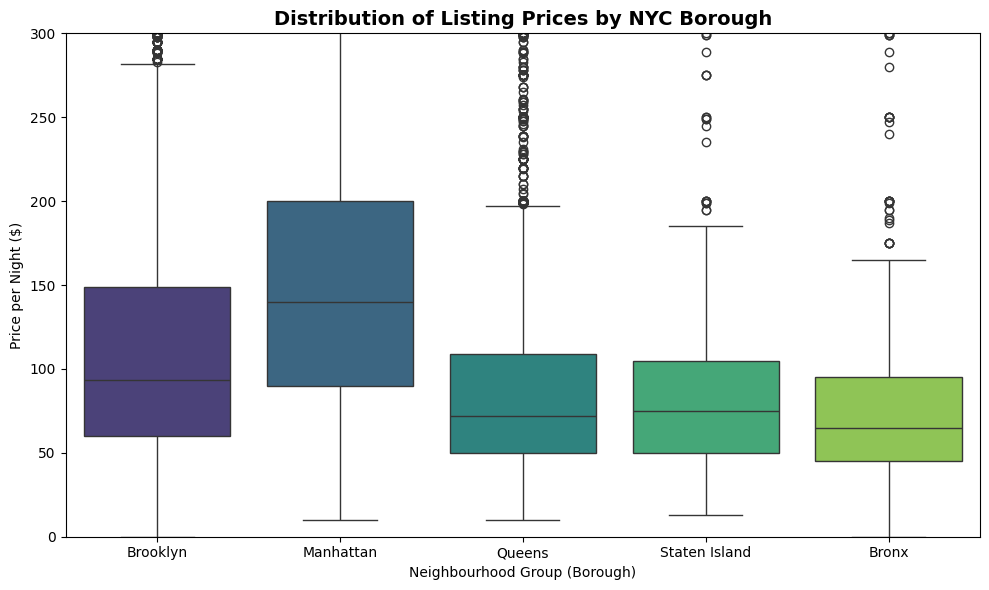

In [ ]:
# Set the style
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))

# Create the boxplot
sns.boxplot(data=df_clean, x='neighbourhood_group', y='price', ax=ax, palette='viridis')
# Set the title and labels
ax.set_title('Distribution of Listing Prices by NYC Borough', fontsize=14, fontweight='bold')
ax.set_xlabel('Neighbourhood Group (Borough)')
ax.set_ylabel('Price per Night ($)')
# Set y-axis limit to focus on the main distribution
ax.set_ylim(0, 300)

plt.tight_layout()
plt.show()

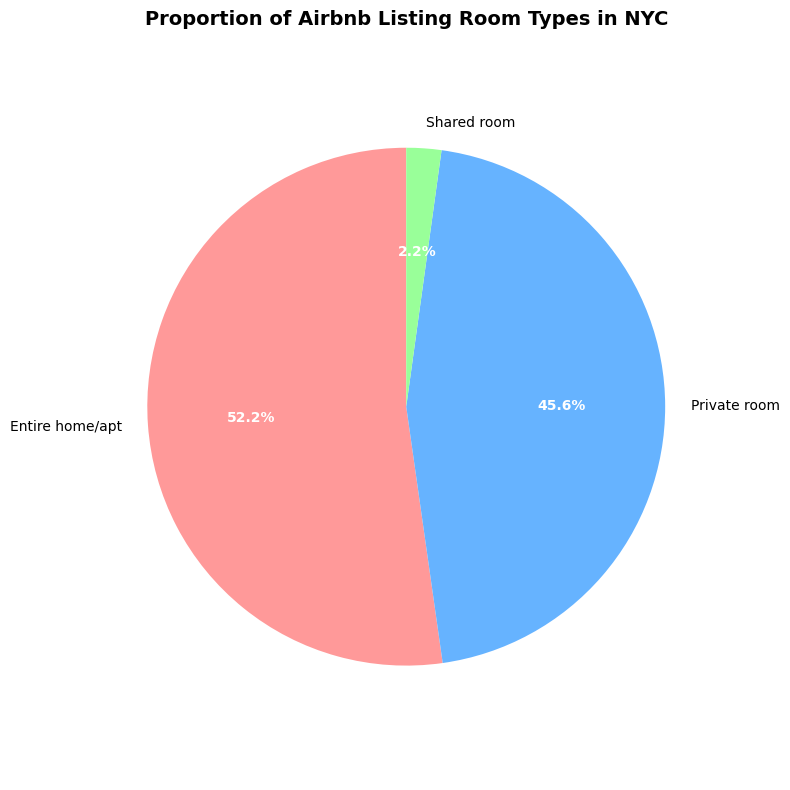

In [ ]:
# Calculate the value counts for room_type
room_type_counts = df_clean['room_type'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(room_type_counts.values,
                                   labels=room_type_counts.index,
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   colors=['#ff9999','#66b3ff','#99ff99'])
# Style the percentages inside the wedges
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
# Ensure the pie is drawn as a circle
plt.axis('equal')
plt.title('Proportion of Airbnb Listing Room Types in NYC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

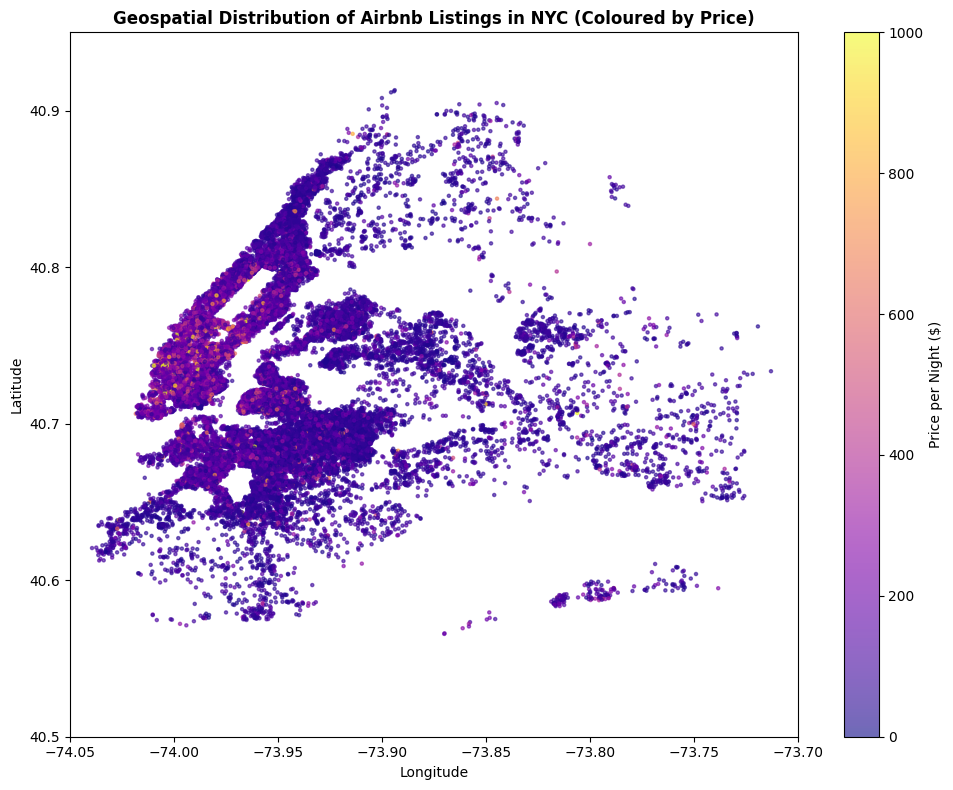

In [ ]:
plt.figure(figsize=(10, 8))
# Create a scatter plot, colouring points by price
scatter = plt.scatter(df_clean['longitude'],
                     df_clean['latitude'],
                     c=df_clean['price'],
                     cmap='plasma',
                     alpha=0.6,
                     s=5) # s controls the size of the points
# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Price per Night ($)')
# Add titles and labels
plt.title('Geospatial Distribution of Airbnb Listings in NYC (Coloured by Price)', fontsize=12, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
# Optional: Add a rough outline of NYC
plt.xlim(-74.05, -73.7)
plt.ylim(40.5, 40.95)

plt.tight_layout()
plt.show()

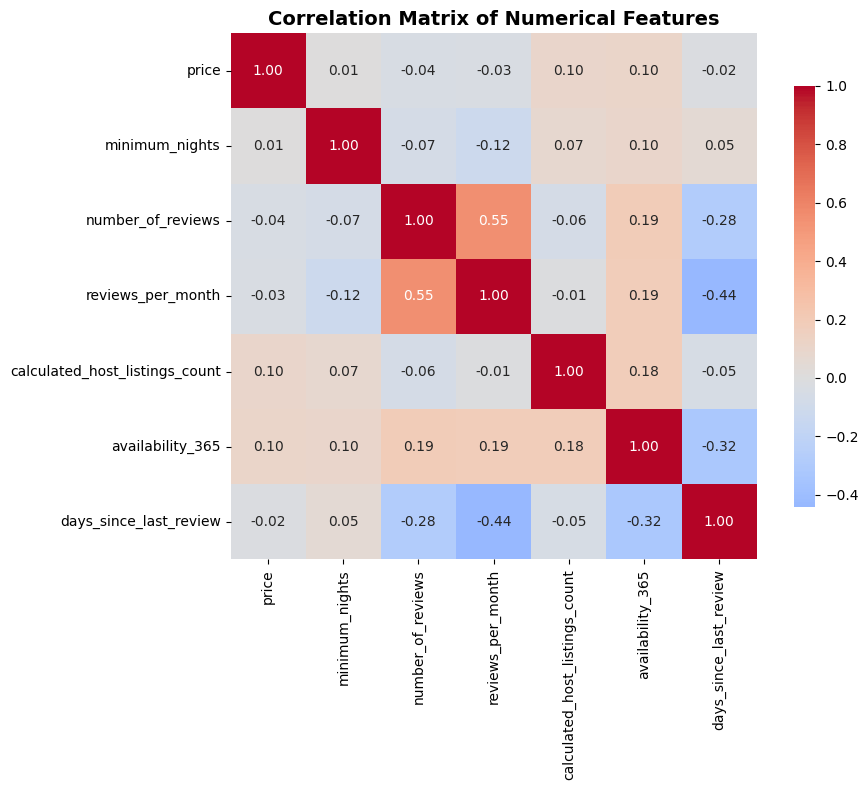

In [ ]:
# Select a subset of numerical features for correlation
numerical_features = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'days_since_last_review']
corr_matrix = df_clean[numerical_features].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True, # Puts the correlation value in each cell
            cmap='coolwarm', # Red-Blue colour scheme
            center=0, # Centers the colormap at 0
            square=True,
            fmt='.2f', # Format annotations to 2 decimal places
            cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

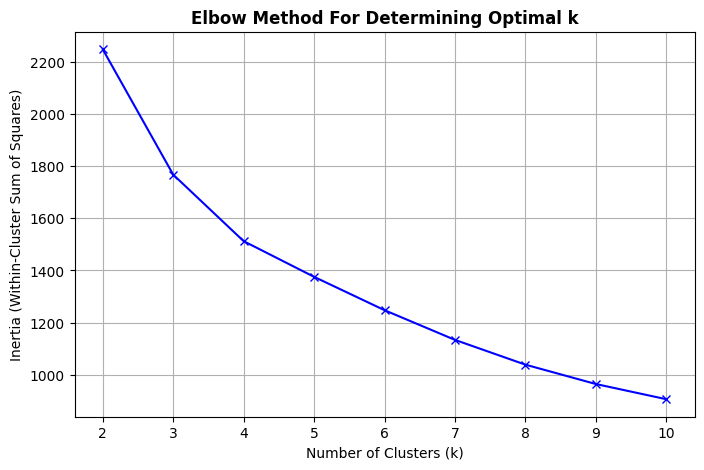

In [ ]:
# 1. Select and scale features for clustering
cluster_features = ['price', 'availability_365', 'latitude', 'longitude']
X_cluster = df_clean[cluster_features].copy()
scaler = MinMaxScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# 2. Calculate inertia for a range of k values
inertias = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

# 3. Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method For Determining Optimal k', fontweight='bold')
plt.xticks(K)
plt.grid(True)
plt.show()

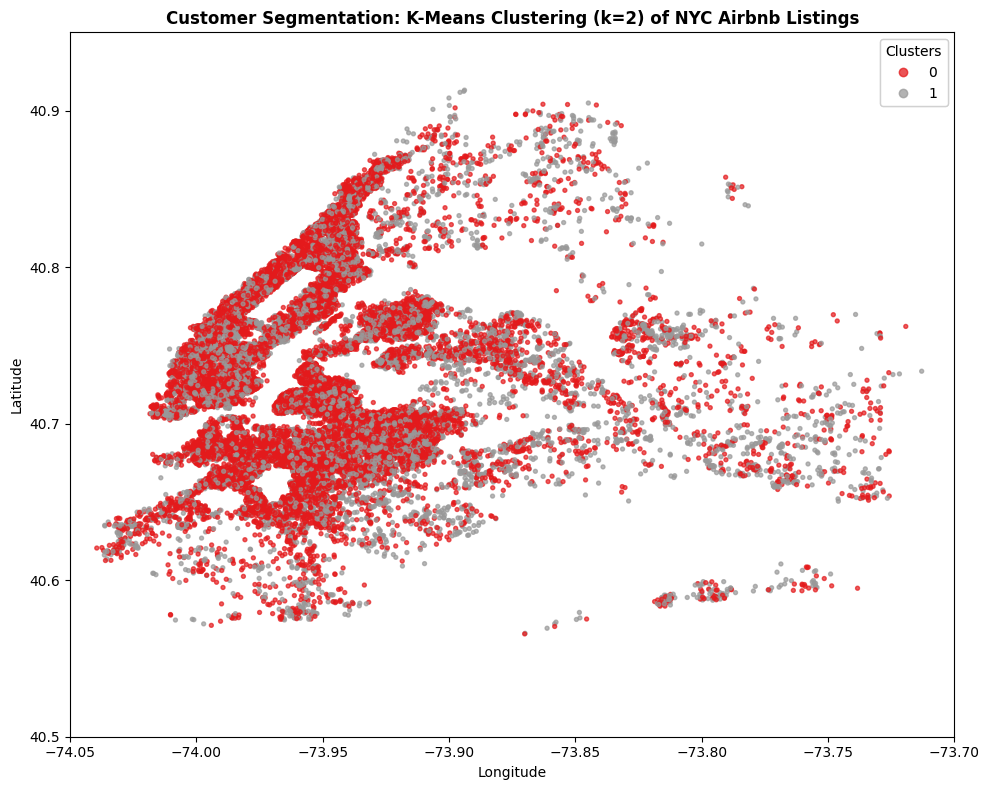

In [ ]:
# Perform K-Means with the chosen k (e.g., k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Plot the results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_clean['longitude'],
                     df_clean['latitude'],
                     c=df_clean['cluster'],
                     cmap='Set1', # Good distinct colours for clusters
                     alpha=0.7,
                     s=8)
# Add a legend for the clusters
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters", loc='upper right')
plt.gca().add_artist(legend1)
# Add titles and labels
plt.title('Customer Segmentation: K-Means Clustering (k=2) of NYC Airbnb Listings', fontsize=12, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-74.05, -73.7)
plt.ylim(40.5, 40.95)

plt.tight_layout()
plt.show()

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data
=== TRACK 1: Classical Machine Learning ===

Files in downloaded directory: ['AB_NYC_2019.csv', 'New_York_City_.png']
Using CSV file: /kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv
Linear Regression: R² = 0.349, RMSE = 82.937
Random Forest: R² = 0.453, RMSE = 76.047
Gradient Boosting: R² = 0.446, RMSE = 76.524


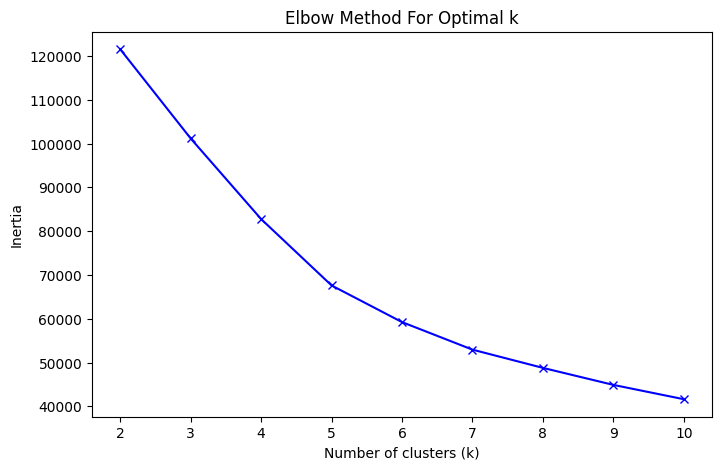


Cluster Profiles:
              price  availability_365
cluster                              
0        158.615624        275.069974
1        123.681225         28.717173


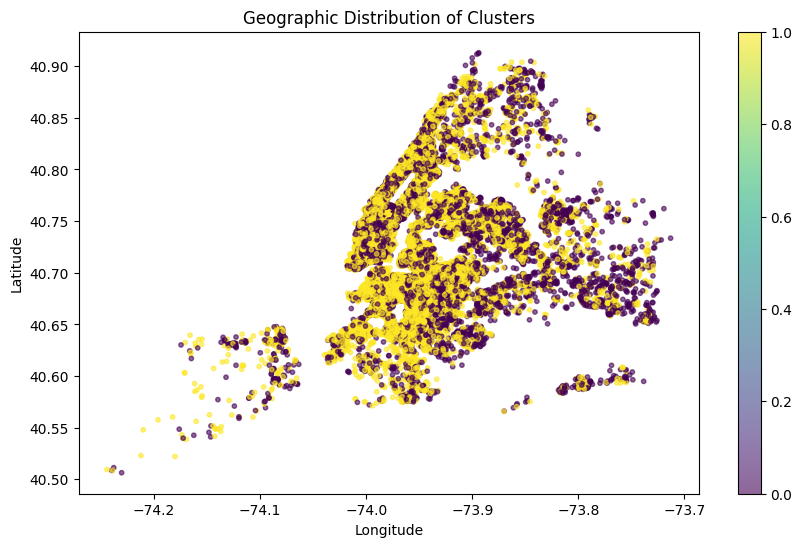


--- Track 1 Complete ---


In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
print("Path to dataset files:", path)

# Track 1: Classical ML - Price Prediction & Clustering
print("=== TRACK 1: Classical Machine Learning ===\n")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load and prep data - MODIFIED TO USE KAGGLEHUB PATH
# First, let's check what files are in the downloaded directory
print("Files in downloaded directory:", os.listdir(path))

# Find the CSV file (it might have a different name)
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    print(f"Using CSV file: {csv_path}")
    df = pd.read_csv(csv_path)
else:
    # If no CSV files found, try the most common name
    try:
        csv_path = os.path.join(path, "AB_NYC_2019.csv")
        df = pd.read_csv(csv_path)
        print("Using AB_NYC_2019.csv")
    except FileNotFoundError:
        # If that doesn't work, try listing all files to see what's available
        all_files = os.listdir(path)
        print("Available files:", all_files)
        raise FileNotFoundError("Could not find CSV file in the downloaded dataset")

df_clean = df.dropna(subset=['last_review', 'reviews_per_month']).copy()
df_clean = df_clean[df_clean['price'] <= 1000]
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'])
df_clean['days_since_last_review'] = (pd.to_datetime('2019-12-31') - df_clean['last_review']).dt.days

# Define features and target
X = df_clean[['neighbourhood_group', 'room_type', 'latitude', 'longitude',
              'minimum_nights', 'number_of_reviews', 'reviews_per_month',
              'calculated_host_listings_count', 'availability_365',
              'days_since_last_review']]
y = df_clean['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing: Encode categoricals, scale numericals
numeric_features = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
                   'reviews_per_month', 'calculated_host_listings_count',
                   'availability_365', 'days_since_last_review']
categorical_features = ['neighbourhood_group', 'room_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Train and evaluate models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {'R2': r2, 'RMSE': rmse}
    print(f"{name}: R² = {r2:.3f}, RMSE = {rmse:.3f}")

# Clustering Analysis
cluster_features = ['price', 'availability_365', 'latitude', 'longitude']
X_cluster = df_clean[cluster_features].copy()
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Find optimal k using Elbow Method
inertias = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

# Apply K-Means with k=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)
df_clean['cluster'] = clusters

# Analyze clusters
cluster_profile = df_clean.groupby('cluster')[['price', 'availability_365']].mean()
print("\nCluster Profiles:")
print(cluster_profile)

# Visualize clusters geographically
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_clean['longitude'], df_clean['latitude'],
                     c=df_clean['cluster'], cmap='viridis', alpha=0.6, s=10)
plt.colorbar(scatter)
plt.title('Geographic Distribution of Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print("\n--- Track 1 Complete ---")

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data
=== TRACK 2: Deep Learning ===

Using CSV file: /kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv
Dataset loaded with 38736 rows
Extracting text features from listing names...
Text features shape: (38736, 500)
Preparing structured data features...
Combined features shape: (38736, 508)
Building deep learning model...
Model summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       130,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,521 (670.00 KB)

 Trainable params: 171,521 (670.00 KB)

 Non-trainable params: 0 (0.00 B)

Training model...
Epoch 1/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 13700.3672 - mae: 76.3247 - val_loss: 8796.3906 - val_mae: 53.8070
Epoch 2/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 7576.2397 - mae: 53.4341 - val_loss: 8302.4453 - val_mae: 52.4508
Epoch 3/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 7404.8496 - mae: 52.7862 - val_loss: 7915.8101 - val_mae: 53.8694
Epoch 4/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 6983.8955 - mae: 51.5208 - val_loss: 7839.1836 - val_mae: 51.5080
Epoch 5/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6818.3535 - mae: 50.4664 - val_loss: 7716.9805 - val_mae: 52.4364
Epoch 6/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6865.2710 - mae: 49.8067 - val_loss: 7586.0942 - val_mae: 51.8851
Epoch 7/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 6326.9604 - mae: 48.2457 - val_loss: 7529.7236 - val_mae: 51.1746
Epoch 8/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 5818.0635 - mae: 47.3017 - val_loss: 75

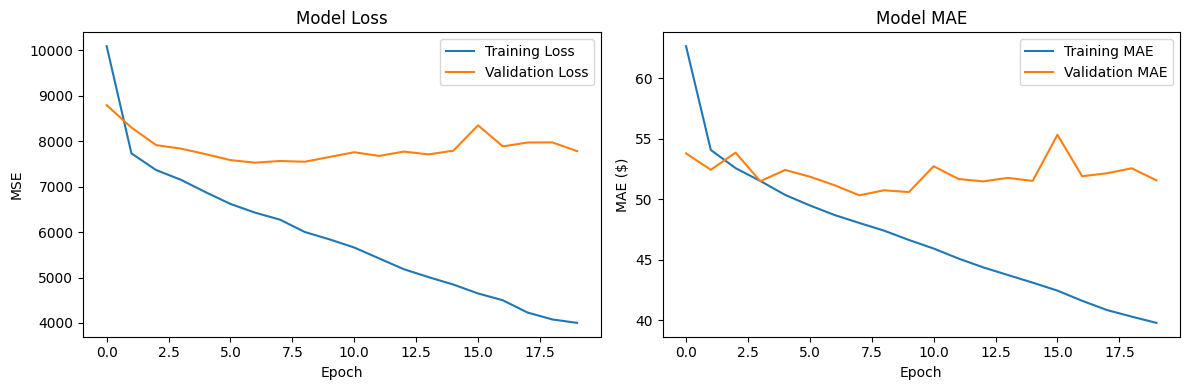

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

Sample predictions vs actual:
Listing 1: Predicted $166.00, Actual $200.00, Error: $34.00
Listing 2: Predicted $84.46, Actual $75.00, Error: $9.46
Listing 3: Predicted $68.23, Actual $85.00, Error: $16.77
Listing 4: Predicted $247.25, Actual $115.00, Error: $132.25
Listing 5: Predicted $266.59, Actual $140.00, Error: $126.59

--- Track 2 Complete ---


In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
print("Path to dataset files:", path)

# Track 2: Deep Learning - Image & Text Analysis
print("=== TRACK 2: Deep Learning ===\n")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, concatenate, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset from kagglehub path
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    print(f"Using CSV file: {csv_path}")
    df = pd.read_csv(csv_path)
else:
    csv_path = os.path.join(path, "AB_NYC_2019.csv")
    df = pd.read_csv(csv_path)

# Basic preprocessing
df_clean = df.dropna(subset=['last_review', 'reviews_per_month']).copy()
df_clean = df_clean[df_clean['price'] <= 1000]
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'])
df_clean['days_since_last_review'] = (pd.to_datetime('2019-12-31') - df_clean['last_review']).dt.days

print(f"Dataset loaded with {len(df_clean)} rows")

# 1. Text Feature Extraction
print("Extracting text features from listing names...")
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
text_features = tfidf.fit_transform(df_clean['name'].fillna('')).toarray()
print(f"Text features shape: {text_features.shape}")

# 2. Structured Data Features
print("Preparing structured data features...")
structured_features = df_clean[['latitude', 'longitude', 'minimum_nights',
                               'number_of_reviews', 'reviews_per_month',
                               'calculated_host_listings_count', 'availability_365',
                               'days_since_last_review']].values

# Scale structured features
scaler = StandardScaler()
structured_features_scaled = scaler.fit_transform(structured_features)

# 3. Combine text and structured features
combined_features = np.concatenate([text_features, structured_features_scaled], axis=1)
print(f"Combined features shape: {combined_features.shape}")

# 4. Target variable
y = df_clean['price'].values

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    combined_features, y, test_size=0.2, random_state=42
)

# 6. Build and train a deep learning model
print("Building deep learning model...")
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='linear')  # Regression output
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("Model summary:")
model.summary()

# Train the model
print("Training model...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest MAE: ${test_mae:.2f}")
print(f"Test Loss (MSE): {test_loss:.2f}")

# 7. Image Feature Extraction (Simulated - would require actual images)
print("\nImage processing simulation:")
print("This dataset doesn't contain actual images, but here's how it would work:")

def simulate_image_processing(listing_ids):
    """Simulate image feature extraction"""
    print(f"Would process images for {len(listing_ids)} listings")
    # In a real scenario, this would:
    # 1. Load images from paths like f"{image_dir}/{listing_id}.jpg"
    # 2. Preprocess them using VGG16/ResNet preprocessing
    # 3. Extract features using a pre-trained model
    # 4. Return feature vectors

    # Return random features for demonstration
    return np.random.rand(len(listing_ids), 512)

# Simulate image feature extraction
image_features = simulate_image_processing(df_clean['id'].head(10).tolist())
print(f"Simulated image features shape: {image_features.shape}")

# 8. Multi-modal architecture example (commented out as it requires images)
"""
print("\nMulti-modal architecture example:")
# This would combine text, structured data, and image features

# Image branch
image_input = Input(shape=(224, 224, 3))
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=image_input)
x = GlobalAveragePooling2D()(base_model.output)
image_branch = Model(inputs=image_input, outputs=x)

# Text + structured data branch (already prepared above)
other_features_input = Input(shape=(combined_features.shape[1],))

# Combine branches
combined = concatenate([image_branch.output, other_features_input])
x = Dense(256, activation='relu')(combined)
x = Dropout(0.4)(x)
output = Dense(1, activation='linear')(x)

multi_modal_model = Model(inputs=[image_input, other_features_input], outputs=output)
multi_modal_model.compile(optimizer=Adam(0.0005), loss='mse', metrics=['mae'])
print("Multi-modal model would be ready for training with actual images")
"""

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE ($)')
plt.legend()

plt.tight_layout()
plt.show()

# Make some predictions
sample_predictions = model.predict(X_test[:5])
print("\nSample predictions vs actual:")
for i, (pred, actual) in enumerate(zip(sample_predictions.flatten(), y_test[:5])):
    print(f"Listing {i+1}: Predicted ${pred:.2f}, Actual ${actual:.2f}, Error: ${abs(pred-actual):.2f}")

print("\n--- Track 2 Complete ---")

=== TRACK 3: Advanced Machine Learning ===



/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Isolation Forest detected 1937 anomalies
One-Class SVM detected 1939 anomalies
Local Outlier Factor detected 1937 anomalies

Top anomalous listings:
                                                 name neighbourhood_group  \
65                       Your Heaven in Hells Kitchen           Manhattan   
106                 Large 2 Bedroom Great for Groups!            Brooklyn   
113                      Park Slope Green Guest House            Brooklyn   
116               2 story family home in Williamsburg            Brooklyn   
235                       SpaHa Studio Monthly Rental           Manhattan   
247               Great East Village Apartment Rental           Manhattan   
299                Unique spacious loft on the Bowery           Manhattan   
365                 2 BR w/ Terrace @ Box House Hotel            Brooklyn   
445               Incredible Prime Williamsburg Loft!            Brooklyn   
563  Sunnyside NYC/ AC room/ city views/ near Midtown              Queens   

   

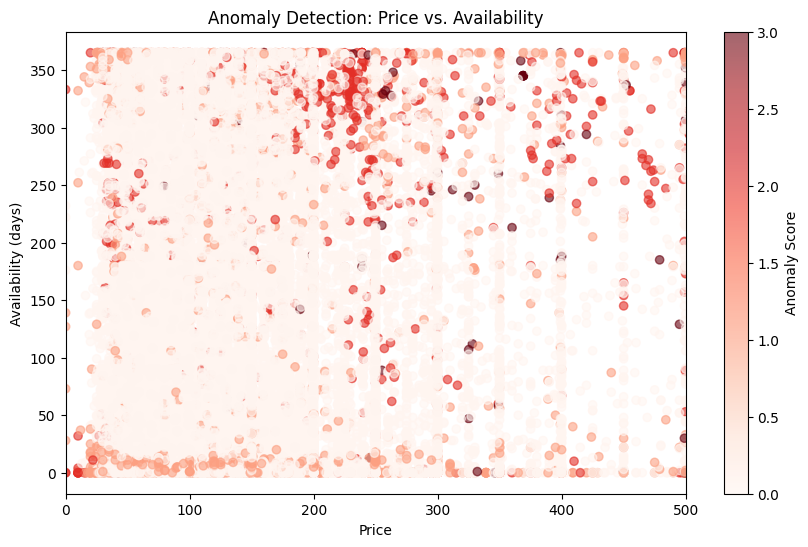


--- Track 3 Complete ---


In [ ]:
# Track 3: Advanced ML - Anomaly Detection
print("=== TRACK 3: Advanced Machine Learning ===\n")

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report

# Prepare features for anomaly detection
anomaly_features = ['price', 'minimum_nights', 'number_of_reviews',
                   'calculated_host_listings_count', 'availability_365']
X_anomaly = df_clean[anomaly_features].copy()

# Handle potential infinite values
X_anomaly = X_anomaly.replace([np.inf, -np.inf], np.nan).dropna()

# Scale the features
scaler = StandardScaler()
X_anomaly_scaled = scaler.fit_transform(X_anomaly)

# 1. Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_predictions = iso_forest.fit_predict(X_anomaly_scaled)
# Convert predictions: -1 (outlier) -> 1, 1 (inlier) -> 0
iso_predictions_binary = [1 if x == -1 else 0 for x in iso_predictions]

# 2. One-Class SVM
oc_svm = OneClassSVM(nu=0.05)
svm_predictions = oc_svm.fit_predict(X_anomaly_scaled)
svm_predictions_binary = [1 if x == -1 else 0 for x in svm_predictions]

# 3. Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_predictions = lof.fit_predict(X_anomaly_scaled)
lof_predictions_binary = [1 if x == -1 else 0 for x in lof_predictions]

# Add predictions to dataframe for analysis
df_anomaly = df_clean.loc[X_anomaly.index].copy()
df_anomaly['iso_forest_anomaly'] = iso_predictions_binary
df_anomaly['svm_anomaly'] = svm_predictions_binary
df_anomaly['lof_anomaly'] = lof_predictions_binary

# Analyze anomalies
print("Isolation Forest detected", sum(iso_predictions_binary), "anomalies")
print("One-Class SVM detected", sum(svm_predictions_binary), "anomalies")
print("Local Outlier Factor detected", sum(lof_predictions_binary), "anomalies")

# Examine top anomalous listings
df_anomaly['total_anomaly_score'] = df_anomaly[['iso_forest_anomaly',
                                               'svm_anomaly',
                                               'lof_anomaly']].sum(axis=1)
top_anomalies = df_anomaly.nlargest(10, 'total_anomaly_score')
print("\nTop anomalous listings:")
print(top_anomalies[['name', 'neighbourhood_group', 'room_type', 'price',
                    'minimum_nights', 'total_anomaly_score']])

# Visualize anomalies in price vs. availability
plt.figure(figsize=(10, 6))
plt.scatter(df_anomaly['price'], df_anomaly['availability_365'],
           c=df_anomaly['total_anomaly_score'], cmap='Reds', alpha=0.6)
plt.colorbar(label='Anomaly Score')
plt.title('Anomaly Detection: Price vs. Availability')
plt.xlabel('Price')
plt.ylabel('Availability (days)')
plt.xlim(0, 500)
plt.show()

print("\n--- Track 3 Complete ---")